In [199]:
from sklearn.datasets import make_circles
X, y = make_circles(n_samples = 100 , random_state=1, noise=0.1)


In [200]:
X.shape

(100, 2)

In [201]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size = 0.2,random_state=42
)

In [202]:
X_train.shape

(80, 2)

In [205]:
import tensorflow
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

In [206]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(2,)),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [207]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_35 (Dense)                │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,049 (195.50 KB)

 Trainable params: 50,049 (195.50 KB)

 Non-trainable params: 0 (0.00 B)

In [208]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [209]:
history = model.fit(X_train,y_train,epochs=300,validation_split=0.2,)

Epoch 1/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 255ms/step - accuracy: 0.4062 - loss: 0.6979 - val_accuracy: 0.5625 - val_loss: 0.6879
Epoch 2/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.5312 - loss: 0.6894 - val_accuracy: 0.6250 - val_loss: 0.6879
Epoch 3/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.5625 - loss: 0.6855 - val_accuracy: 0.5625 - val_loss: 0.6847
Epoch 4/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.5781 - loss: 0.6820 - val_accuracy: 0.5625 - val_loss: 0.6813
Epoch 5/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.5469 - loss: 0.6790 - val_accuracy: 0.5625 - val_loss: 0.6790
Epoch 6/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.5625 - loss: 0.6763 - val_accuracy: 0.5625 - val_loss: 0.6763
Epoch 7/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.5312 - loss: 0.6743 - val_accuracy: 0.6250 - val_loss: 0.6734
Epoch 8/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.5469 - loss: 0.6705 - val_accuracy: 0.5625 - val_loss

Text(0.5, 1.0, 'Overfitting')

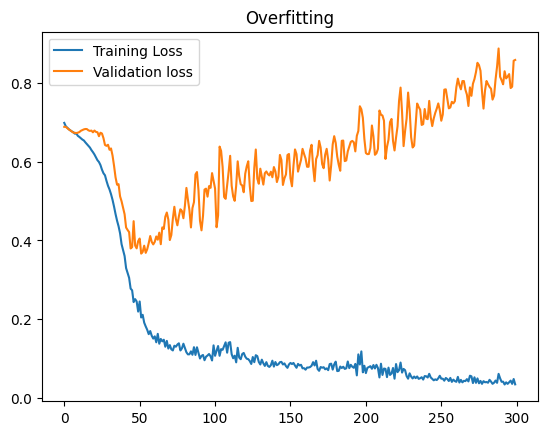

In [210]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation loss')
plt.legend()
plt.title('Overfitting')

# Here we see that it is the case of the Overfitting so we apply Earlystopppin to the model when overfitting occurs atomatically


In [211]:
import tensorflow as tf
from tensorflow import keras

# Check if hardware acceleration is active
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))


Num GPUs Available:  0


# Earlystopping


In [219]:
earlystop = EarlyStopping(
    monitor="val_loss",
    min_delta=0.00001,
    patience=10,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0,
)

In [220]:
historyl = model.fit(X_train,y_train,epochs=3000,validation_split=0.2,callbacks=earlystop)

Epoch 1/3000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.9844 - loss: 0.0283 - val_accuracy: 0.8125 - val_loss: 0.8703
Epoch 2/3000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9844 - loss: 0.0456 - val_accuracy: 0.8125 - val_loss: 0.9054
Epoch 3/3000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9688 - loss: 0.0492 - val_accuracy: 0.8125 - val_loss: 0.8742
Epoch 4/3000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9844 - loss: 0.0513 - val_accuracy: 0.8125 - val_loss: 0.8598
Epoch 5/3000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9844 - loss: 0.0320 - val_accuracy: 0.8125 - val_loss: 0.8625
Epoch 6/3000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9844 - loss: 0.0558 - val_accuracy: 0.8125 - val_loss: 0.9180
Epoch 7/3000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9844 - loss: 0.0488 - val_accuracy: 0.8125 - val_loss: 0.8361
Epoch 8/3000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9844 - loss: 0.0447 - val_accuracy: 0.8125 - 

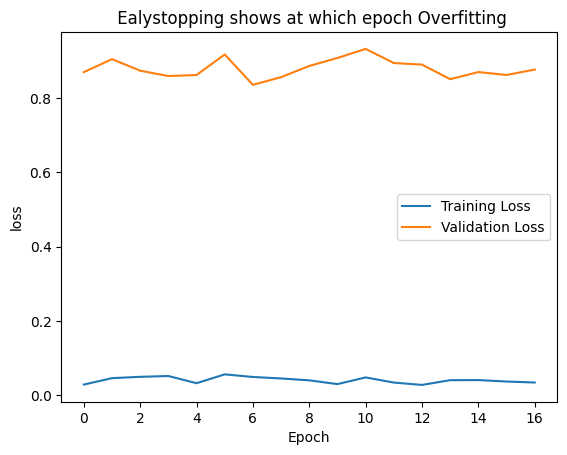

In [221]:
import matplotlib.pyplot as plt
plt.plot(historyl.history['loss'],label='Training Loss')
plt.plot(historyl.history['val_loss'],label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.title(' Ealystopping shows at which epoch Overfitting')
plt.legend()

In [222]:
earlystopa = EarlyStopping(
    monitor="val_accuracy",
    min_delta=0,
    patience=10,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0,
)

In [223]:
historya = model.fit(X_train,y_train,epochs=3000,validation_split=0.2,callbacks=earlystopa)

Epoch 1/3000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.9844 - loss: 0.0296 - val_accuracy: 0.8125 - val_loss: 0.9122
Epoch 2/3000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9688 - loss: 0.0360 - val_accuracy: 0.7500 - val_loss: 0.8938
Epoch 3/3000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9688 - loss: 0.0290 - val_accuracy: 0.7500 - val_loss: 0.8993
Epoch 4/3000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9844 - loss: 0.0378 - val_accuracy: 0.7500 - val_loss: 0.9077
Epoch 5/3000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9688 - loss: 0.0416 - val_accuracy: 0.8125 - val_loss: 0.8725
Epoch 6/3000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9844 - loss: 0.0345 - val_accuracy: 0.8125 - val_loss: 0.8850
Epoch 7/3000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9844 - loss: 0.0296 - val_accuracy: 0.7500 - val_loss: 0.9207
Epoch 8/3000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9844 - loss: 0.0345 - val_accuracy: 0.7500 - 

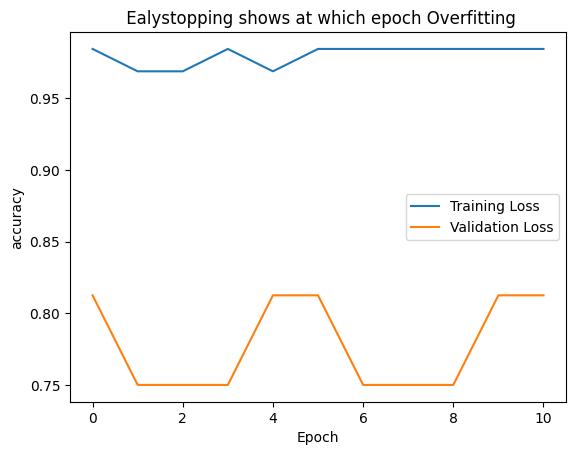

In [224]:
import matplotlib.pyplot as plt
plt.plot(historya.history['accuracy'],label='Training Loss')
plt.plot(historya.history['val_accuracy'],label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('accuracy')
plt.title(' Ealystopping shows at which epoch Overfitting')
plt.legend()